# Module 01 - Data Audit and Preprocessing

Notebook này kiểm tra dữ liệu gốc, chuẩn hóa schema, xác định leakage
columns và tạo split train/dev/test cố định.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
from pizza_dss.business_analysis import dtype_audit, redundant_feature_audit, synthetic_data_audit
from pizza_dss.config import FEATURE_COLUMNS, LEAKAGE_COLUMNS
from pizza_dss.data_loader import (
    audit_dataset,
    export_processed_splits,
    load_dataset,
    validate_feature_contract,
)
from pizza_dss.data_forensics import infer_delay_threshold

## 0. Định nghĩa thuật ngữ tiền xử lý

- **Schema**: tập cột + kiểu dữ liệu. **snake_case**: chuẩn hóa tên cột.
- **Leakage (rò rỉ)**: dùng thông tin chỉ biết *sau* khi giao hàng làm
  feature dự báo → kết quả ảo. Ở đây gồm duration/delay/efficiency/
  restaurant_avg_time vì chúng định nghĩa hoặc suy ra nhãn.
- **Stratified split**: chia train/dev/test giữ nguyên tỷ lệ trễ ở mỗi
  phần, để dev/test đại diện đúng cho phân phối nhãn.
- **Feature contract**: ràng buộc code chặn mọi feature nằm trong danh
  sách leakage (raise lỗi nếu vi phạm).

## 1. Load and schema

In [2]:
df = load_dataset()
df.shape, df.head()

((1004, 37),
   order_id restaurant_name         location          order_time  \
 0   ORD001        Domino's     New York, NY 2024-01-05 18:30:00   
 1   ORD002     Papa John's  Los Angeles, CA 2024-02-14 20:00:00   
 2   ORD003  Little Caesars      Chicago, IL 2024-03-21 12:15:00   
 3   ORD004       Pizza Hut        Miami, FL 2024-04-10 19:45:00   
 4   ORD005   Marco's Pizza       Dallas, TX 2024-05-05 13:00:00   
 
         delivery_time  delivery_duration_min pizza_size    pizza_type  \
 0 2024-01-05 18:45:00                     15     Medium           Veg   
 1 2024-02-14 20:25:00                     25      Large       Non-Veg   
 2 2024-03-21 12:35:00                     20      Small         Vegan   
 3 2024-04-10 20:10:00                     25         XL  Cheese Burst   
 4 2024-05-05 13:20:00                     20     Medium       Non-Veg   
 
    toppings_count  distance_km  ... order_month_num pizza_size_score  \
 0               3          2.5  ...               1      

In [3]:
dtype_audit(df)

,column,dtype,missing,nunique,sample_values
0,order_id,str,0,1004,"ORD001, ORD002, ORD003, ORD004, ORD005"
1,restaurant_name,str,0,5,"Domino's, Papa John's, Little Caesars, Pizza H..."
2,location,str,0,84,"New York, NY, Los Angeles, CA, Chicago, IL, Mi..."
3,order_time,datetime64[us],0,968,"2024-01-05 18:30:00, 2024-02-14 20:00:00, 2024..."
4,delivery_time,datetime64[us],0,980,"2024-01-05 18:45:00, 2024-02-14 20:25:00, 2024..."
5,delivery_duration_min,int64,0,8,"15, 25, 20, 30, 40"
6,pizza_size,str,0,4,"Medium, Large, Small, XL"
7,pizza_type,str,0,12,"Veg, Non-Veg, Vegan, Cheese Burst, Gluten-Free"
8,toppings_count,int64,0,5,"3, 4, 2, 5, 1"
9,distance_km,float64,0,25,"2.5, 5.0, 3.0, 4.5, 2.0"


**Insight (schema).** 1.004 đơn, 37 cột sau FE, không có cột nào sai kiểu rõ rệt; bảng này là tham chiếu kiểu/dtype cho các bước sau.

### 1b. Audit lẫn int/float

Dữ liệu trộn kiểu int và float. Cell dưới chỉ ra cột nào *lưu dạng float
nhưng giá trị thực ra là số nguyên* — dấu hiệu generator sinh số rồi ép
kiểu, và là lý do ta mã hóa/ép kiểu nhất quán khi xây feature.

In [4]:
numeric = df.select_dtypes("number")
audit = pd.DataFrame({
    "column": numeric.columns,
    "dtype": [str(numeric[c].dtype) for c in numeric.columns],
    "is_integer_valued": [bool((numeric[c].dropna() % 1 == 0).all()) for c in numeric.columns],
})
audit["stored_as_float_but_integer"] = audit["dtype"].str.startswith("float") & audit["is_integer_valued"]
audit

,column,dtype,is_integer_valued,stored_as_float_but_integer
0,delivery_duration_min,int64,True,False
1,toppings_count,int64,True,False
2,distance_km,float64,False,False
3,delivery_efficiency_min_per_km,float64,False,False
4,topping_density,float64,False,False
5,estimated_duration_min,float64,False,False
6,delay_min,float64,False,False
7,pizza_complexity,int64,True,False
8,traffic_impact,int64,True,False
9,order_hour,int64,True,False


**Insight (int/float).** Các cột `stored_as_float_but_integer=True` (vd toppings, order_hour) bản chất là số nguyên bị lưu float — vô hại cho mô hình sau khi StandardScaler, nhưng được ghi nhận như một dấu hiệu synthetic.

## 2. Feature engineering cho size/time/complexity

In [5]:
df[[
    "pizza_size", "pizza_size_score", "pizza_size_code", "pizza_size_label",
    "time_segment", "complexity_band", "distance_band", "order_period"
]].head()

,pizza_size,pizza_size_score,pizza_size_code,pizza_size_label,time_segment,complexity_band,distance_band,order_period
0,Medium,2,02,02_Medium,Dinner,Medium,0-3 km,2024-01
1,Large,3,03,03_Large,Dinner,High,3-6 km,2024-02
2,Small,1,01,01_Small,Lunch,Low,0-3 km,2024-03
3,XL,4,04,04_XL,Dinner,Very High,3-6 km,2024-04
4,Medium,2,02,02_Medium,Lunch,Medium,0-3 km,2024-05


In [6]:
df.groupby(["pizza_size_score", "pizza_size_label"]).size().reset_index(name="orders")

,pizza_size_score,pizza_size_label,orders
0,1,01_Small,132
1,2,02_Medium,429
2,3,03_Large,240
3,4,04_XL,203


## 3. Leakage and synthetic-data audit

In [7]:
audit_dataset(df)

{'rows': 1004,
 'columns': 37,
 'missing_total': 0,
 'duplicate_order_ids': 0,
 'date_min': '2024-01-05 18:30:00',
 'date_max': '2026-07-07 20:00:00',
 'years': {'2024': 443, '2025': 373, '2026': 188},
 'target_distribution': {'False': 794, 'True': 210},
 'delayed_rate': 0.2092,
 'is_delayed_equals_duration_gt_30': True,
 'max_delay_formula_error': 0.0,
 'chronological_last20_rows': 201,
 'chronological_last20_delayed': 0,
 'feature_columns': ['toppings_count',
  'distance_km',
  'topping_density',
  'estimated_duration_min',
  'pizza_complexity',
  'traffic_impact',
  'order_hour',
  'restaurant_name',
  'location',
  'pizza_size',
  'pizza_type',
  'traffic_level',
  'payment_method',
  'is_peak_hour',
  'is_weekend',
  'order_month',
  'payment_category'],
 'blocked_leakage_columns': ['delivery_time',
  'delivery_duration_min',
  'delivery_efficiency_min_per_km',
  'delay_min',
  'restaurant_avg_time']}

`is_delayed` là nhãn có sẵn trong file, nhưng file không giải thích
SLA bao nhiêu phút thì trễ. Vì vậy ta suy luận ranh giới nhãn bằng
cách thử các luật ngưỡng trên `delivery_duration_min` và đếm số dòng
mismatch.

In [8]:
infer_delay_threshold(df).head(8)

,rule,operator,threshold_minutes,mismatches,mismatch_rate,accuracy,false_positives,false_negatives,predicted_delayed,actual_delayed,exact_match,max_observed_on_time_duration,min_observed_delayed_duration,interpretation
0,delivery_duration_min > 30,>,30.0,0,0.000000,1.000000,0,0,210,210,True,30.0,35.0,Observationally exact on this 5-minute duratio...
1,delivery_duration_min >= 35,>=,35.0,0,0.000000,1.000000,0,0,210,210,True,30.0,35.0,Observationally exact on this 5-minute duratio...
2,delivery_duration_min > 35,>,35.0,44,0.043825,0.956175,0,44,166,210,False,30.0,35.0,Does not reproduce the provided label exactly.
3,delivery_duration_min >= 40,>=,40.0,44,0.043825,0.956175,0,44,166,210,False,30.0,35.0,Does not reproduce the provided label exactly.
4,delivery_duration_min > 40,>,40.0,136,0.135458,0.864542,0,136,74,210,False,30.0,35.0,Does not reproduce the provided label exactly.
5,delivery_duration_min >= 45,>=,45.0,136,0.135458,0.864542,0,136,74,210,False,30.0,35.0,Does not reproduce the provided label exactly.
6,delivery_duration_min > 45,>,45.0,170,0.169323,0.830677,0,170,40,210,False,30.0,35.0,Does not reproduce the provided label exactly.
7,delivery_duration_min >= 50,>=,50.0,170,0.169323,0.830677,0,170,40,210,False,30.0,35.0,Does not reproduce the provided label exactly.


In [9]:
synthetic_data_audit(df)

,check,severity,evidence,interpretation
0,No missing values,warning,0 missing cells across 37 columns,"Clean data is useful, but a zero-missing opera..."
1,Future timestamp relative to analysis date,warning,"max order_time=2026-07-07 20:00:00, analysis_d...","The file title says 2024-25, but rows reach Ju..."
2,Label is deterministic from delivery duration,critical,True,"delivery_duration_min, delay_min and delivery_..."
3,Estimated duration formula,warning,max |estimated_duration_min - 2.4 * distance_k...,estimated_duration_min is a deterministic tran...
4,Topping density formula,warning,max |topping_density - toppings_count / distan...,topping_density duplicates information already...
5,Pizza complexity formula,warning,max |pizza_complexity - toppings_count * size_...,pizza_complexity is engineered from toppings_c...
6,Traffic impact is only encoded traffic level,warning,"unique traffic_impact values=[1, 2, 3]",traffic_impact is redundant with traffic_level.
7,Delivery duration has few discrete values,warning,"8 unique values: [15, 20, 25, 30, 35, 40, 45, 50]",Real delivery duration usually has richer minu...
8,Order hour support is narrow,warning,8 unique hours; 94.2% are 18-20h,This is useful for dinner-peak staffing but to...
9,Distance support is discretized,warning,25 unique distances across 1004 rows,Distances look sampled from a short menu of va...


In [10]:
redundant_feature_audit(df)

,column,source_or_formula,max_abs_error,model_action
0,estimated_duration_min,2.4 * distance_km,3.552714e-15,Drop in compact feature set; keep distance_km.
1,topping_density,toppings_count / distance_km,2.220446e-16,Drop in compact feature set; keep base variables.
2,pizza_complexity,toppings_count * pizza_size_score,0.000000e+00,Use for interpretation; compact model uses siz...
3,traffic_impact,"Low=1, Medium=2, High=3",0.000000e+00,Drop in compact feature set; keep traffic_level.
4,delay_min,delivery_duration_min - estimated_duration_min,3.552714e-15,Block as leakage.
5,delivery_efficiency_min_per_km,delivery_duration_min / distance_km,0.000000e+00,Block as leakage.
6,restaurant_avg_time,group statistic from delivery duration,NaN,Block as post-hoc aggregate leakage.


In [11]:
{
    "feature_columns": FEATURE_COLUMNS,
    "blocked_leakage_columns": LEAKAGE_COLUMNS,
    "feature_contract_passed": validate_feature_contract(),
}

{'feature_columns': ['toppings_count',
  'distance_km',
  'topping_density',
  'estimated_duration_min',
  'pizza_complexity',
  'traffic_impact',
  'order_hour',
  'restaurant_name',
  'location',
  'pizza_size',
  'pizza_type',
  'traffic_level',
  'payment_method',
  'is_peak_hour',
  'is_weekend',
  'order_month',
  'payment_category'],
 'blocked_leakage_columns': ['delivery_time',
  'delivery_duration_min',
  'delivery_efficiency_min_per_km',
  'delay_min',
  'restaurant_avg_time'],
 'feature_contract_passed': True}

## 3b. Hình minh hoạ dữ liệu và ranh giới nhãn

**Lý do.** Hai biểu đồ dưới cho thấy lớp trễ là thiểu số và nhãn nằm
đúng trên lưới 5 phút: nhóm on-time tối đa 30 phút, nhóm delayed tối
thiểu 35 phút.

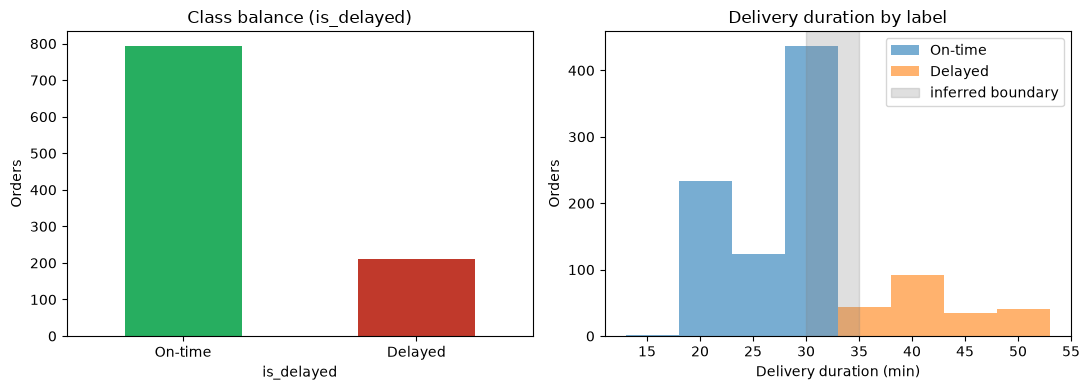

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["is_delayed"].value_counts().rename({False: "On-time", True: "Delayed"}).plot.bar(
    ax=axes[0], color=["#27ae60", "#c0392b"]
)
axes[0].set_title("Class balance (is_delayed)")
axes[0].set_ylabel("Orders")
axes[0].tick_params(axis="x", rotation=0)
for label, group in df.groupby("is_delayed"):
    axes[1].hist(
        group["delivery_duration_min"],
        bins=range(13, 56, 5),
        alpha=0.6,
        label=("Delayed" if label else "On-time"),
    )
axes[1].axvspan(30, 35, color="grey", alpha=0.25, label="inferred boundary")
axes[1].set_title("Delivery duration by label")
axes[1].set_xlabel("Delivery duration (min)")
axes[1].set_ylabel("Orders")
axes[1].legend()
fig.tight_layout()
plt.show()

**Insight.** Tỷ lệ trễ ~21% nên Accuracy đơn lẻ sẽ đánh lừa; cần F2/
Recall cùng Balanced Accuracy/MCC. Ranh giới nhãn là suy luận từ dữ
liệu, củng cố quyết định chặn duration/delay khỏi feature.

## 4. Processed splits

In [13]:
export_processed_splits()

{'train': 602, 'dev': 201, 'test': 201}

In [14]:
splits = {
    name: pd.read_csv(PROJECT_ROOT / "data" / "processed" / f"{name}.csv")
    for name in ["train", "dev", "test"]
}
pd.DataFrame([
    {
        "split": name,
        "rows": len(frame),
        "delayed": int(frame["is_delayed"].sum()),
        "delayed_rate": frame["is_delayed"].mean(),
    }
    for name, frame in splits.items()
])

,split,rows,delayed,delayed_rate
0,train,602,126,0.209302
1,dev,201,42,0.208955
2,test,201,42,0.208955


### 4b. Kiểm tra split không rò rỉ

Hai điều phải đúng: (1) không `order_id` nào xuất hiện ở hơn một split;
(2) tỷ lệ trễ được giữ gần như nhau giữa các split (stratify).

In [15]:
ids = {name: set(frame["order_id"]) for name, frame in splits.items()}
overlaps = {
    "train∩dev": len(ids["train"] & ids["dev"]),
    "train∩test": len(ids["train"] & ids["test"]),
    "dev∩test": len(ids["dev"] & ids["test"]),
}
pd.DataFrame([
    {"check": "row_id_overlaps_between_splits", **overlaps},
])

,check,train∩dev,train∩test,dev∩test
0,row_id_overlaps_between_splits,0,0,0


**Insight (rò rỉ split).** Mọi giao tập `order_id` = 0 → không đơn nào lọt sang split khác; cùng với tỷ lệ trễ ~21% giữ đều (bảng mục 4), split là leakage-safe và đại diện.

## 5. Insight → quyết định tiền xử lý

In [16]:
pd.DataFrame([
    {
        "question": "Có missing/duplicate không?",
        "evidence": "missing_total=0, duplicate_order_ids=0 trong audit_dataset.",
        "decision": "Không cần imputation; nhưng zero-missing là dấu hiệu synthetic, ghi vào audit.",
    },
    {
        "question": "Nhãn is_delayed định nghĩa thế nào?",
        "evidence": "is_delayed == (delivery_duration_min > 30), mismatch=0.",
        "decision": "Chặn duration/delay/efficiency/restaurant_avg_time khỏi feature.",
    },
    {
        "question": "Cột nào trùng thông tin?",
        "evidence": "estimated_duration=2.4*distance; complexity=toppings*size; density=toppings/distance.",
        "decision": "Dùng compact feature set, bỏ cột công thức, giữ pizza_size_score.",
    },
    {
        "question": "Split thế nào?",
        "evidence": "Chronological last-20% có 0 delayed.",
        "decision": "Dùng stratified train/dev/test 602/201/201, ghi rõ giới hạn.",
    },
])

,question,evidence,decision
0,Có missing/duplicate không?,"missing_total=0, duplicate_order_ids=0 trong a...",Không cần imputation; nhưng zero-missing là dấ...
1,Nhãn is_delayed định nghĩa thế nào?,"is_delayed == (delivery_duration_min > 30), mi...",Chặn duration/delay/efficiency/restaurant_avg_...
2,Cột nào trùng thông tin?,estimated_duration=2.4*distance; complexity=to...,"Dùng compact feature set, bỏ cột công thức, gi..."
3,Split thế nào?,Chronological last-20% có 0 delayed.,"Dùng stratified train/dev/test 602/201/201, gh..."


Kết luận: dataset gốc đủ nhỏ để xử lý offline bằng pandas/scikit-learn.
Pipeline giữ raw Excel trong thư mục dự án con và sinh processed CSV
để notebook, dashboard và PowerBI dùng chung.